# Assignment 8 — House Prices Regression Mini-Project

**Objective:** Predict sale prices of houses using tabular features (categorical + numerical).  
**Dataset:** Ames Housing (`house_price_prediction_dataset.csv`)  
**Primary metric:** RMSE &nbsp;|&nbsp; **Secondary metric:** RMSLE (on log-transformed target)

## 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


---
## 1 — Problem Setup & Data Loading

In [2]:
df = pd.read_csv('house_price_prediction_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


---
## 2 — Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

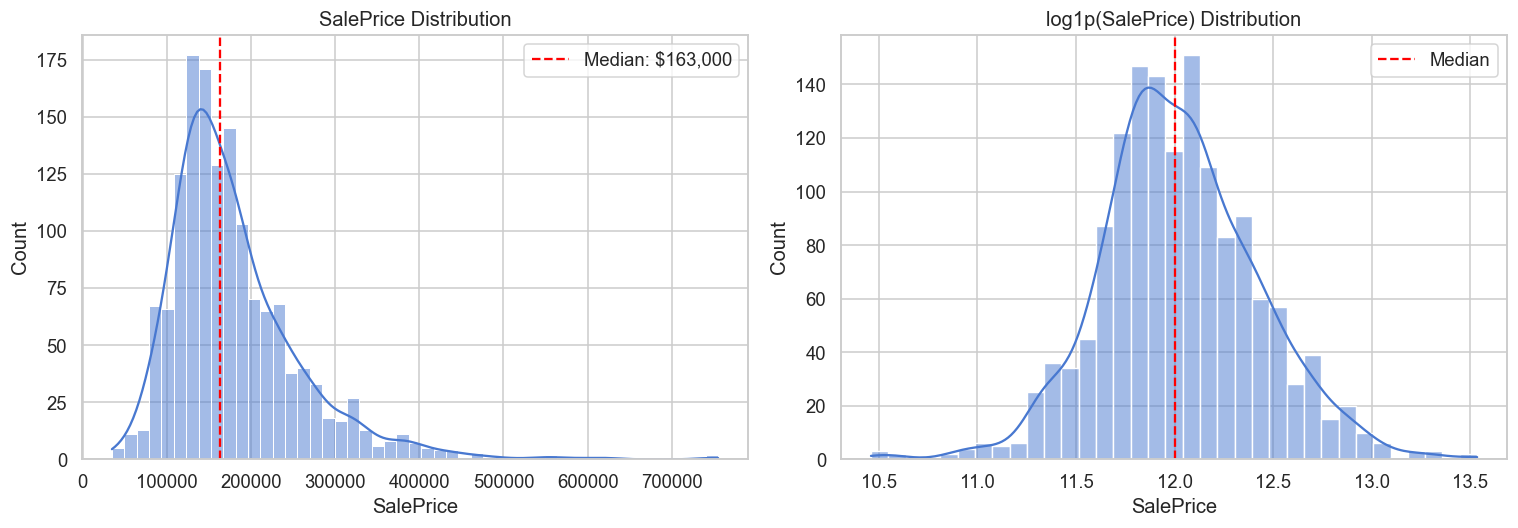

Skewness  : 1.88
Kurtosis  : 6.54
After log : skew = 0.12


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')
axes[0].axvline(df['SalePrice'].median(), color='red', ls='--', label=f"Median: ${df['SalePrice'].median():,.0f}")
axes[0].legend()

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('log1p(SalePrice) Distribution')
axes[1].axvline(np.log1p(df['SalePrice']).median(), color='red', ls='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Skewness  : {df['SalePrice'].skew():.2f}")
print(f"Kurtosis  : {df['SalePrice'].kurtosis():.2f}")
print(f"After log : skew = {np.log1p(df['SalePrice']).skew():.2f}")

**Observation:** SalePrice is right-skewed. A log-transform normalises it well, which is useful for linear models and as an RMSLE-friendly approach.

### 2.2 Missing Values Analysis

19 columns with missing values:



,Count,Percent
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


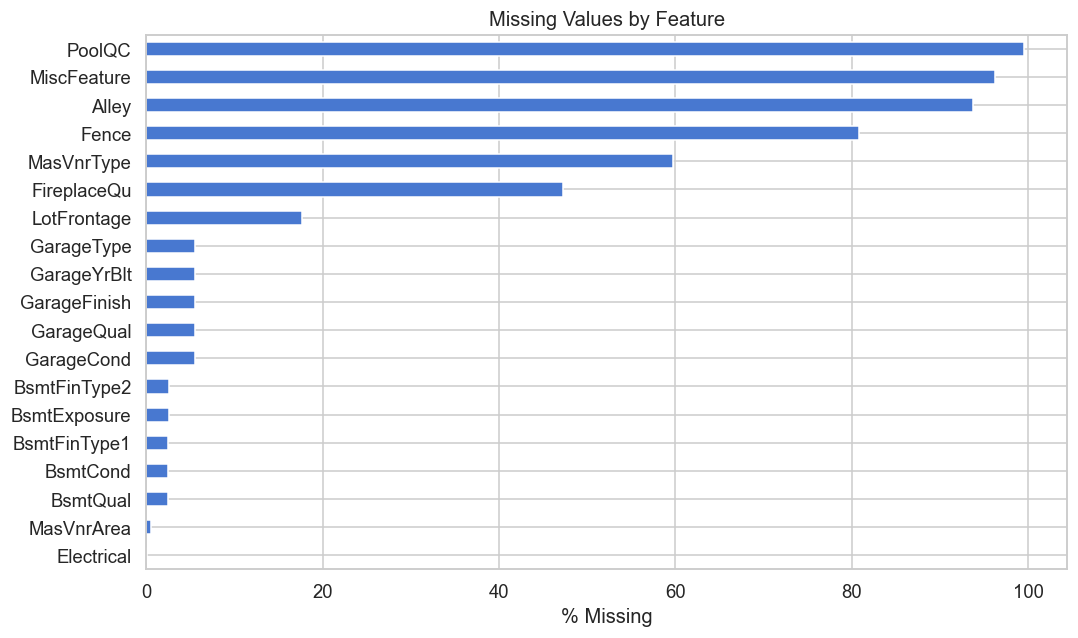

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(f'{len(miss_df)} columns with missing values:\n')
display(miss_df)

fig, ax = plt.subplots(figsize=(10, 6))
miss_df['Percent'].plot.barh(ax=ax)
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Key points:**
- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu` have >40 % missing — NA here generally means *feature absent* (no pool, no alley, etc.).
- `LotFrontage` (~18 %) is numeric and will be imputed with the median.
- `GarageYrBlt` missing where there is no garage.
- Remaining columns have <5 % missing and can be safely imputed.

### 2.3 Numeric Feature Correlations with SalePrice

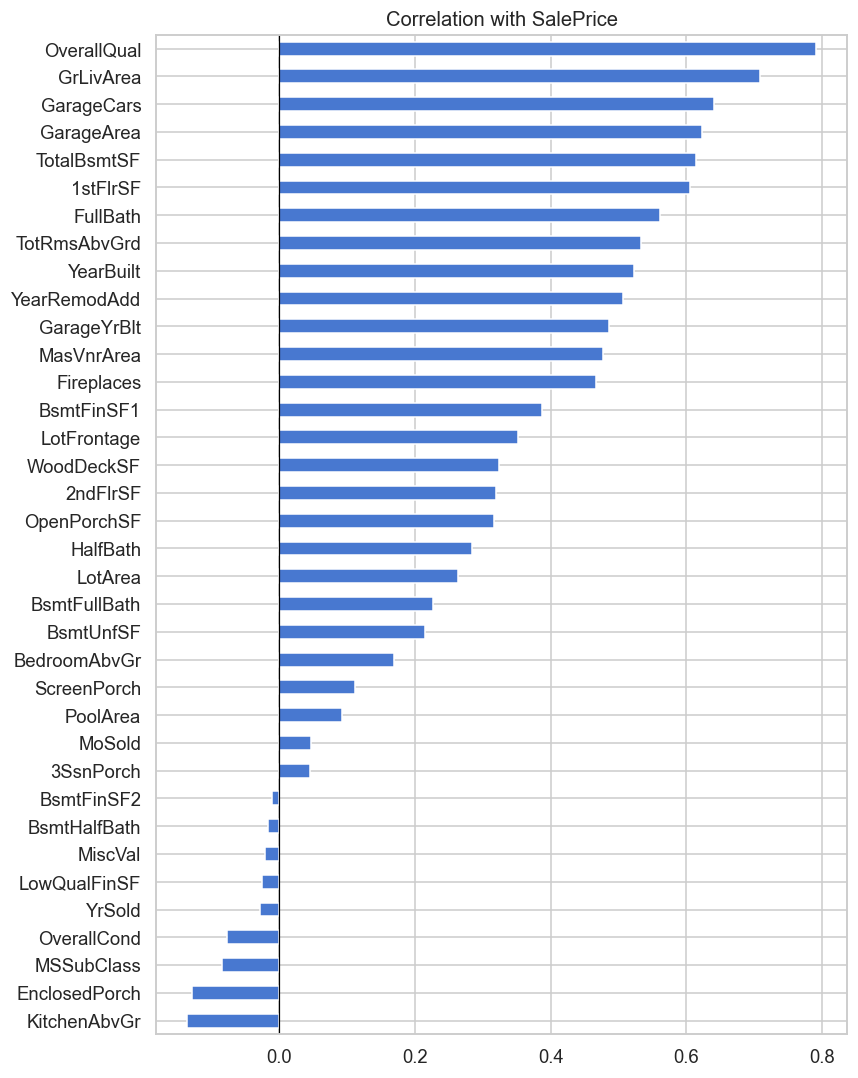

Top 10 positive correlations:


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ('Id',)]

corr = df[num_cols].corr()
sale_corr = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sale_corr.plot.barh(ax=ax)
ax.set_title('Correlation with SalePrice')
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 positive correlations:')
display(sale_corr.head(10))

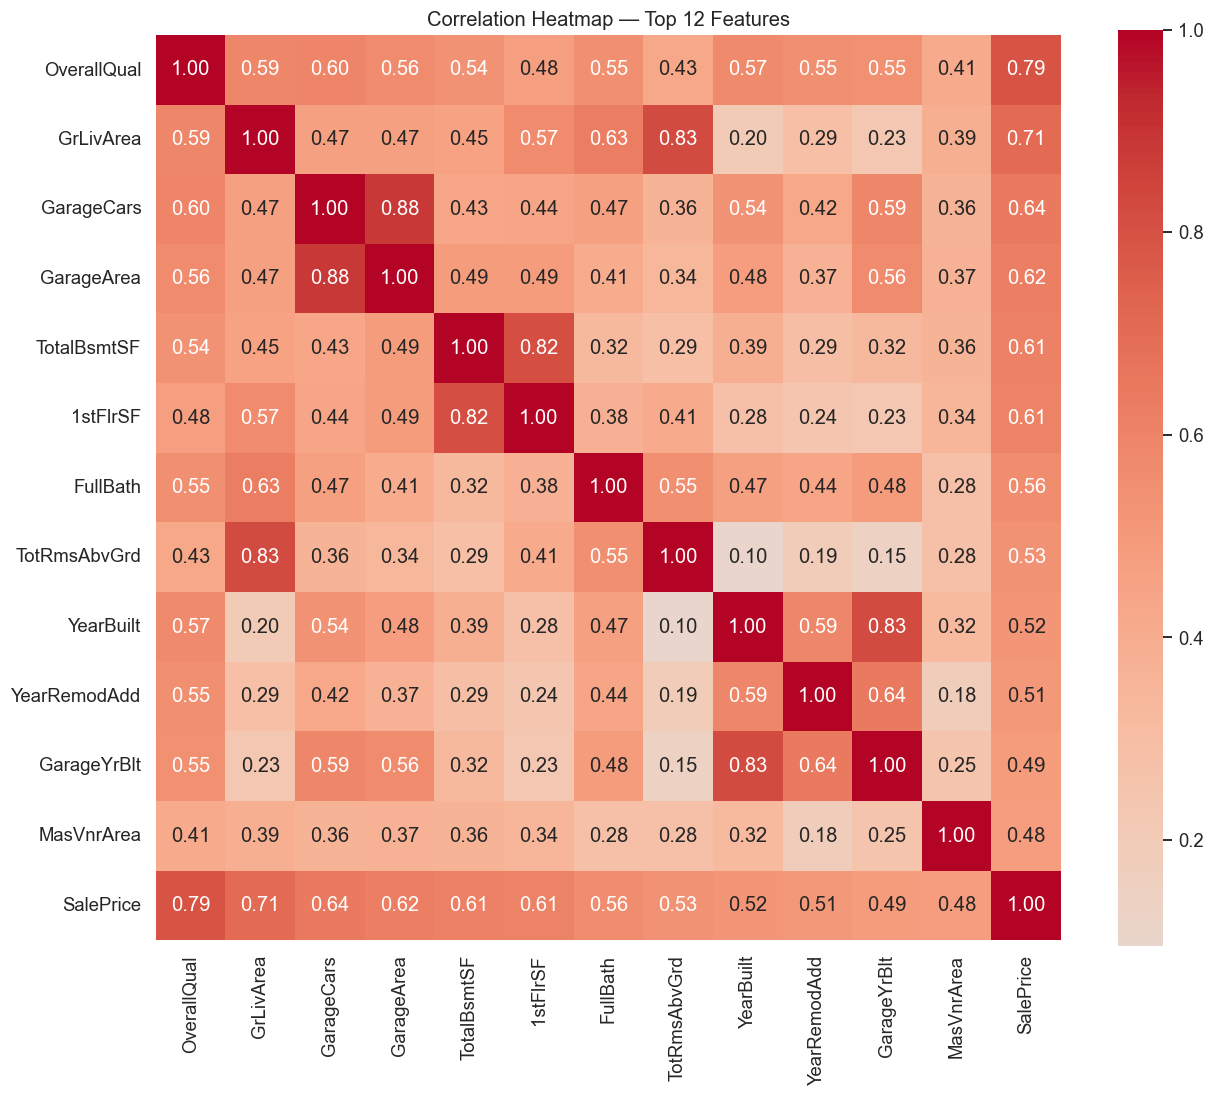

In [8]:
top_corr_features = sale_corr.abs().sort_values(ascending=False).head(12).index.tolist()
top_corr_features.append('SalePrice')

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Top 12 Features')
plt.tight_layout()
plt.show()

### 2.4 Key Bi-variate Plots (Features vs SalePrice)

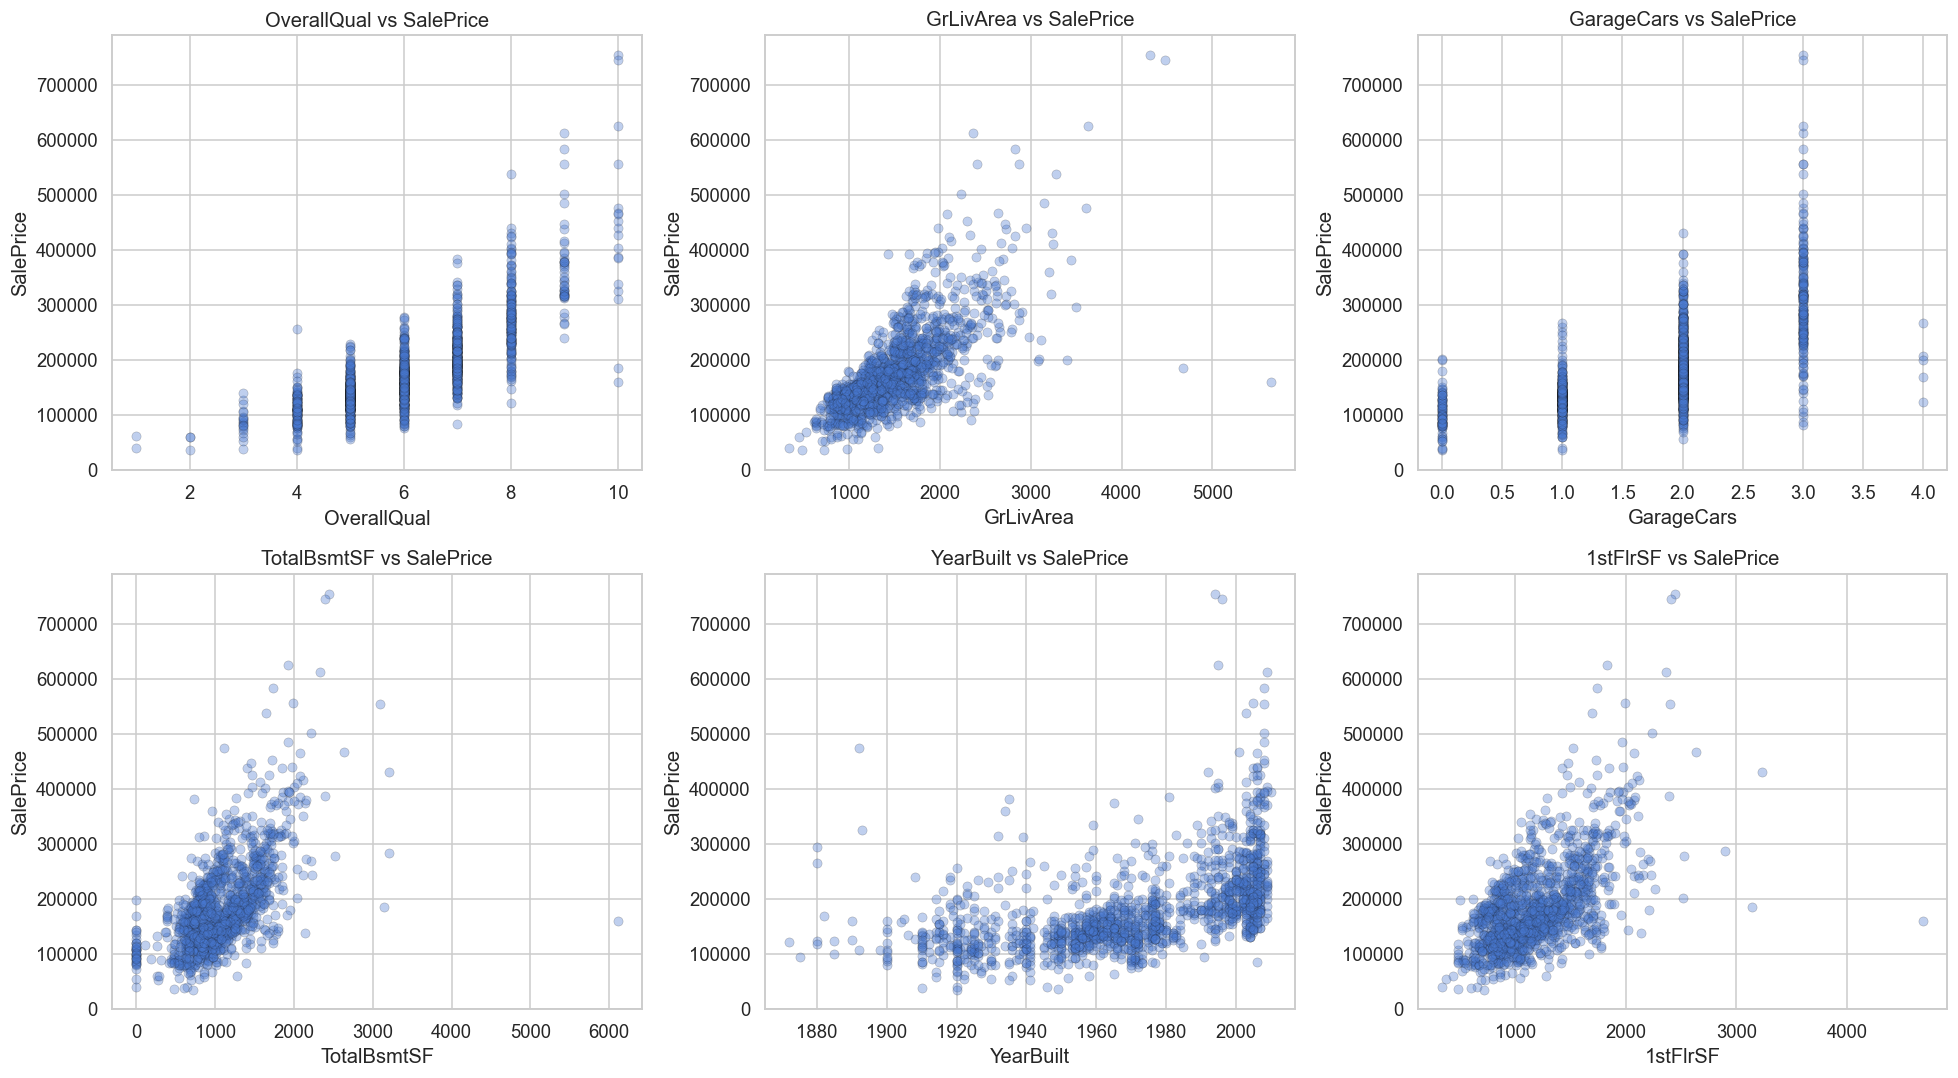

In [9]:
scatter_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                    'YearBuilt', '1stFlrSF']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.ravel(), scatter_features):
    ax.scatter(df[feat], df['SalePrice'], alpha=0.35, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.show()

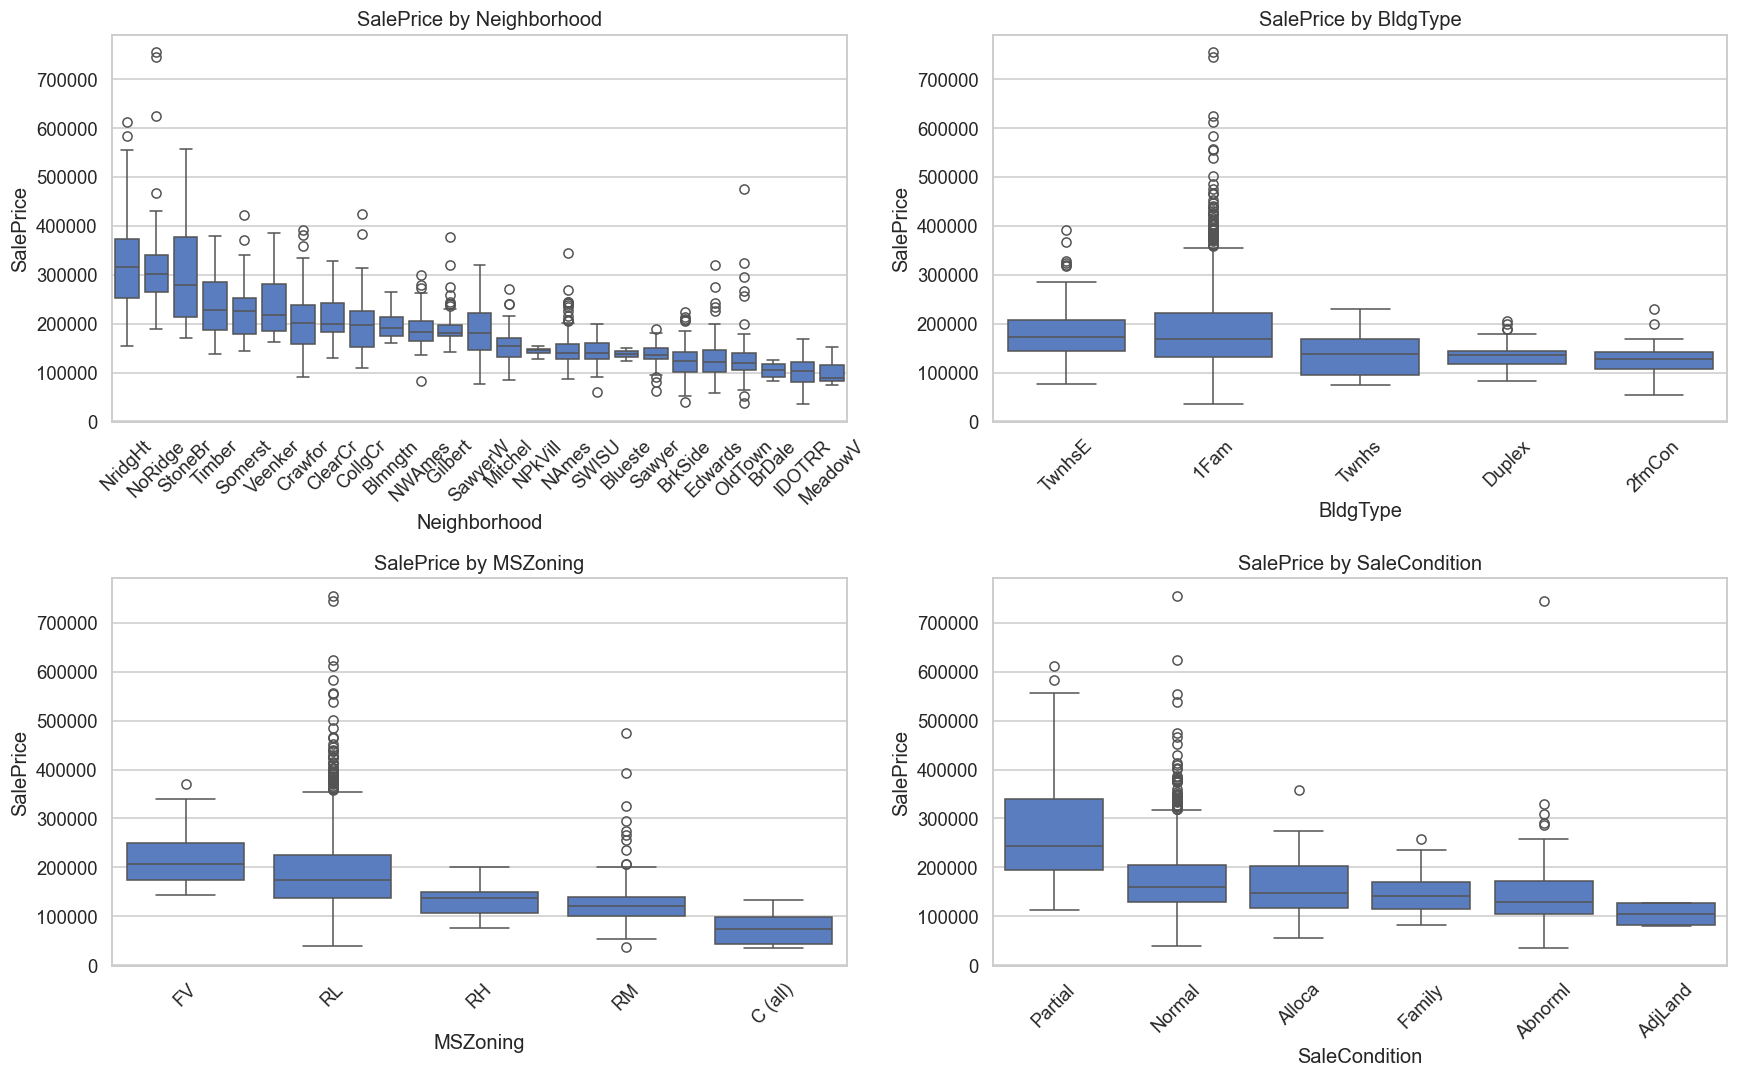

In [10]:
cat_features_eda = ['Neighborhood', 'BldgType', 'MSZoning', 'SaleCondition']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.ravel(), cat_features_eda):
    order = df.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='SalePrice', order=order, ax=ax)
    ax.set_title(f'SalePrice by {feat}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**EDA Summary:**
- `OverallQual` and `GrLivArea` are the strongest numeric predictors.
- Garage capacity, basement size, and year built are also highly correlated.
- Neighbourhood has a large effect on price, with `NoRidge`, `NridgHt`, and `StoneBr` at the top.
- A few outliers with very large `GrLivArea` but low `SalePrice` may need attention.

---
## 3 — Preprocessing & Baseline Models

### 3.1 Feature / Target Split & Train-Test Split

In [11]:
df_model = df.drop(columns=['Id'])

X = df_model.drop(columns=['SalePrice'])
y = df_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')

Train size: (1168, 79)  |  Test size: (292, 79)


### 3.2 Identify Numeric & Categorical Columns

In [12]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numeric features   : {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')

Numeric features   : 36
Categorical features: 43


### 3.3 Preprocessing Pipeline

In [13]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

print('Preprocessing pipeline defined.')

Preprocessing pipeline defined.


### 3.4 Baseline Models

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    y_pred_clip = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, results):
    pipeline.fit(X_tr, y_tr)
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test = pipeline.predict(X_te)

    cv_scores = cross_val_score(pipeline, X_tr, y_tr,
                                cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()

    train_rmse = rmse(y_tr, y_pred_train)
    test_rmse  = rmse(y_te, y_pred_test)
    test_rmsle_val = rmsle(y_te, y_pred_test)

    results.append({
        'Model': name,
        'Train RMSE': round(train_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'CV RMSE (mean±std)': f'{cv_rmse:,.0f} ± {cv_std:,.0f}',
        'Test RMSLE': round(test_rmsle_val, 4),
    })
    print(f'{name:30s}  Train RMSE={train_rmse:>10,.0f}  Test RMSE={test_rmse:>10,.0f}  CV RMSE={cv_rmse:>10,.0f}')
    return pipeline

In [15]:
results = []

baselines = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10, random_state=SEED),
    'Lasso (alpha=100)': Lasso(alpha=100, random_state=SEED, max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
}

fitted_pipelines = {}
for name, model in baselines.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results)

pd.DataFrame(results)

Linear Regression               Train RMSE=    18,960  Test RMSE=1,768,793,457,987,925  CV RMSE=659,463,778,474,762
Ridge (alpha=10)                Train RMSE=    24,359  Test RMSE=    30,521  CV RMSE=    32,637


Lasso (alpha=100)               Train RMSE=    22,001  Test RMSE=    28,225  CV RMSE=    33,052
Decision Tree                   Train RMSE=    23,014  Test RMSE=    42,126  CV RMSE=    44,335


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18959.60,1.768793e+15,"659,463,778,474,762 ± 1,005,018,910,249,415",2.9471
1,Ridge (alpha=10),24358.84,3.052093e+04,"32,637 ± 9,407",0.1573
2,Lasso (alpha=100),22000.55,2.822465e+04,"33,052 ± 8,813",0.1456
3,Decision Tree,23013.61,4.212622e+04,"44,335 ± 10,165",0.2143


---
## 4 — Advanced Models & Feature Engineering

### 4.1 Advanced Models (Default Hyper-parameters)

In [16]:
advanced_models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                                   max_depth=4, random_state=SEED),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.1,
                            max_depth=4, random_state=SEED,
                            verbosity=0, n_jobs=-1),
}

for name, model in advanced_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results)

pd.DataFrame(results)

Random Forest                   Train RMSE=    11,129  Test RMSE=    29,229  CV RMSE=    30,625


Gradient Boosting               Train RMSE=     4,661  Test RMSE=    26,573  CV RMSE=    29,933


XGBoost                         Train RMSE=     5,431  Test RMSE=    25,307  CV RMSE=    29,017


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18959.60,1.768793e+15,"659,463,778,474,762 ± 1,005,018,910,249,415",2.9471
1,Ridge (alpha=10),24358.84,3.052093e+04,"32,637 ± 9,407",0.1573
2,Lasso (alpha=100),22000.55,2.822465e+04,"33,052 ± 8,813",0.1456
3,Decision Tree,23013.61,4.212622e+04,"44,335 ± 10,165",0.2143
4,Random Forest,11128.55,2.922864e+04,"30,625 ± 4,733",0.1530
5,Gradient Boosting,4661.50,2.657345e+04,"29,933 ± 4,618",0.1419
6,XGBoost,5430.76,2.530726e+04,"29,017 ± 4,443",0.1362


### 4.2 Feature Engineering

We add domain-driven features and apply log-transforms on skewed numeric variables.

In [17]:
def add_features(df_in):
    df_fe = df_in.copy()
    df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
    df_fe['TotalBath'] = (df_fe['FullBath'] + 0.5 * df_fe['HalfBath']
                          + df_fe['BsmtFullBath'] + 0.5 * df_fe['BsmtHalfBath'])
    df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch']
                              + df_fe['3SsnPorch'] + df_fe['ScreenPorch'])
    df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
    df_fe['RemodAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
    df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
    df_fe['HasBsmt'] = (df_fe['TotalBsmtSF'] > 0).astype(int)
    df_fe['Has2ndFlr'] = (df_fe['2ndFlrSF'] > 0).astype(int)
    df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
    return df_fe

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

numeric_features_fe = X_train_fe.select_dtypes(include='number').columns.tolist()
categorical_features_fe = X_train_fe.select_dtypes(include='object').columns.tolist()

preprocessor_fe = ColumnTransformer([
    ('num', numeric_transformer, numeric_features_fe),
    ('cat', categorical_transformer, categorical_features_fe),
])

print(f'Engineered feature set: {X_train_fe.shape[1]} features ({len(numeric_features_fe)} num, {len(categorical_features_fe)} cat)')

Engineered feature set: 88 features (45 num, 43 cat)


### 4.3 Feature Selection via Lasso

In [18]:
lasso_pipe = Pipeline([('preprocessor', preprocessor_fe),
                        ('model', Lasso(alpha=50, random_state=SEED, max_iter=10000))])
lasso_pipe.fit(X_train_fe, y_train)

ohe_names = lasso_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features_fe)
all_feat_names = np.array(numeric_features_fe + list(ohe_names))
lasso_coefs = lasso_pipe.named_steps['model'].coef_
nonzero = np.sum(lasso_coefs != 0)
print(f'Lasso kept {nonzero} / {len(lasso_coefs)} features (alpha=50)')

Lasso kept 149 / 310 features (alpha=50)


### 4.4 Re-train Advanced Models with Engineered Features

In [19]:
fe_models = {
    'Ridge + FE': Ridge(alpha=10, random_state=SEED),
    'Random Forest + FE': RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    'Gradient Boosting + FE': GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                                        max_depth=4, random_state=SEED),
    'XGBoost + FE': XGBRegressor(n_estimators=300, learning_rate=0.1,
                                  max_depth=4, random_state=SEED,
                                  verbosity=0, n_jobs=-1),
}

for name, model in fe_models.items():
    pipe = Pipeline([('preprocessor', preprocessor_fe), ('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train_fe, y_train, X_test_fe, y_test, results)

pd.DataFrame(results)

Ridge + FE                      Train RMSE=    23,888  Test RMSE=    30,080  CV RMSE=    32,575


Random Forest + FE              Train RMSE=    10,813  Test RMSE=    29,187  CV RMSE=    29,583


Gradient Boosting + FE          Train RMSE=     4,304  Test RMSE=    27,819  CV RMSE=    27,784


XGBoost + FE                    Train RMSE=     5,366  Test RMSE=    25,510  CV RMSE=    29,011


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18959.60,1.768793e+15,"659,463,778,474,762 ± 1,005,018,910,249,415",2.9471
1,Ridge (alpha=10),24358.84,3.052093e+04,"32,637 ± 9,407",0.1573
2,Lasso (alpha=100),22000.55,2.822465e+04,"33,052 ± 8,813",0.1456
3,Decision Tree,23013.61,4.212622e+04,"44,335 ± 10,165",0.2143
4,Random Forest,11128.55,2.922864e+04,"30,625 ± 4,733",0.1530
5,Gradient Boosting,4661.50,2.657345e+04,"29,933 ± 4,618",0.1419
6,XGBoost,5430.76,2.530726e+04,"29,017 ± 4,443",0.1362
7,Ridge + FE,23888.02,3.008005e+04,"32,575 ± 9,822",0.1554
8,Random Forest + FE,10812.79,2.918662e+04,"29,583 ± 4,520",0.1515
9,Gradient Boosting + FE,4303.87,2.781863e+04,"27,784 ± 3,513",0.1434


### 4.5 Hyperparameter Tuning (XGBoost + FE)

In [20]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1)),
])

param_grid = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb_pipe, param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_fe, y_train)

print(f'\nBest CV RMSE: {-grid_search.best_score_:,.0f}')
print(f'Best params : {grid_search.best_params_}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits



Best CV RMSE: 26,897
Best params : {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 0.8}


In [21]:
best_pipe = grid_search.best_estimator_
fitted_pipelines['XGBoost Tuned + FE'] = evaluate_model(
    'XGBoost Tuned + FE', best_pipe,
    X_train_fe, y_train, X_test_fe, y_test, results
)

pd.DataFrame(results)

XGBoost Tuned + FE              Train RMSE=     5,446  Test RMSE=    24,755  CV RMSE=    26,897


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18959.60,1.768793e+15,"659,463,778,474,762 ± 1,005,018,910,249,415",2.9471
1,Ridge (alpha=10),24358.84,3.052093e+04,"32,637 ± 9,407",0.1573
2,Lasso (alpha=100),22000.55,2.822465e+04,"33,052 ± 8,813",0.1456
3,Decision Tree,23013.61,4.212622e+04,"44,335 ± 10,165",0.2143
4,Random Forest,11128.55,2.922864e+04,"30,625 ± 4,733",0.1530
5,Gradient Boosting,4661.50,2.657345e+04,"29,933 ± 4,618",0.1419
6,XGBoost,5430.76,2.530726e+04,"29,017 ± 4,443",0.1362
7,Ridge + FE,23888.02,3.008005e+04,"32,575 ± 9,822",0.1554
8,Random Forest + FE,10812.79,2.918662e+04,"29,583 ± 4,520",0.1515
9,Gradient Boosting + FE,4303.87,2.781863e+04,"27,784 ± 3,513",0.1434


---
## 5 — Model Evaluation & Communication

### 5.1 Model Comparison Table

In [22]:
results_df = pd.DataFrame(results)
display(results_df.style.highlight_min(subset=['Test RMSE', 'Test RMSLE'], color='#d4edda'))

,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18959.600000,1768793457987925.000000,"659,463,778,474,762 ± 1,005,018,910,249,415",2.947100
1,Ridge (alpha=10),24358.840000,30520.930000,"32,637 ± 9,407",0.157300
2,Lasso (alpha=100),22000.550000,28224.650000,"33,052 ± 8,813",0.145600
3,Decision Tree,23013.610000,42126.220000,"44,335 ± 10,165",0.214300
4,Random Forest,11128.550000,29228.640000,"30,625 ± 4,733",0.153000
5,Gradient Boosting,4661.500000,26573.450000,"29,933 ± 4,618",0.141900
6,XGBoost,5430.760000,25307.260000,"29,017 ± 4,443",0.136200
7,Ridge + FE,23888.020000,30080.050000,"32,575 ± 9,822",0.155400
8,Random Forest + FE,10812.790000,29186.620000,"29,583 ± 4,520",0.151500
9,Gradient Boosting + FE,4303.870000,27818.630000,"27,784 ± 3,513",0.143400


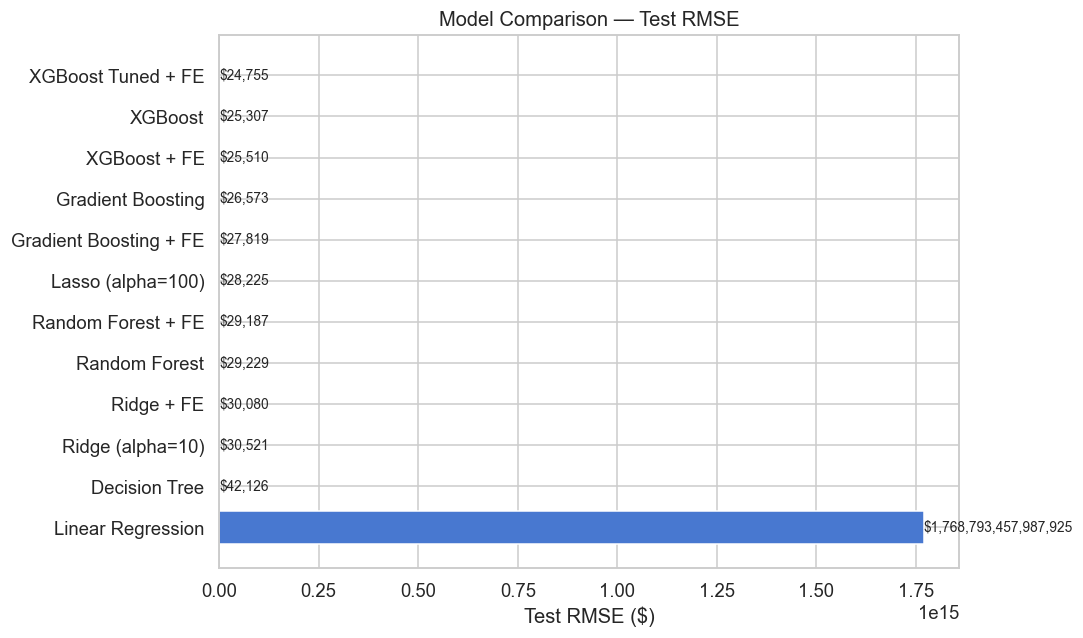

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
results_df_sorted = results_df.sort_values('Test RMSE')
bars = ax.barh(results_df_sorted['Model'], results_df_sorted['Test RMSE'])
ax.set_xlabel('Test RMSE ($)')
ax.set_title('Model Comparison — Test RMSE')
ax.invert_yaxis()
for bar, val in zip(bars, results_df_sorted['Test RMSE']):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Feature Importance (Best Model)

Best model by Test RMSE: XGBoost Tuned + FE


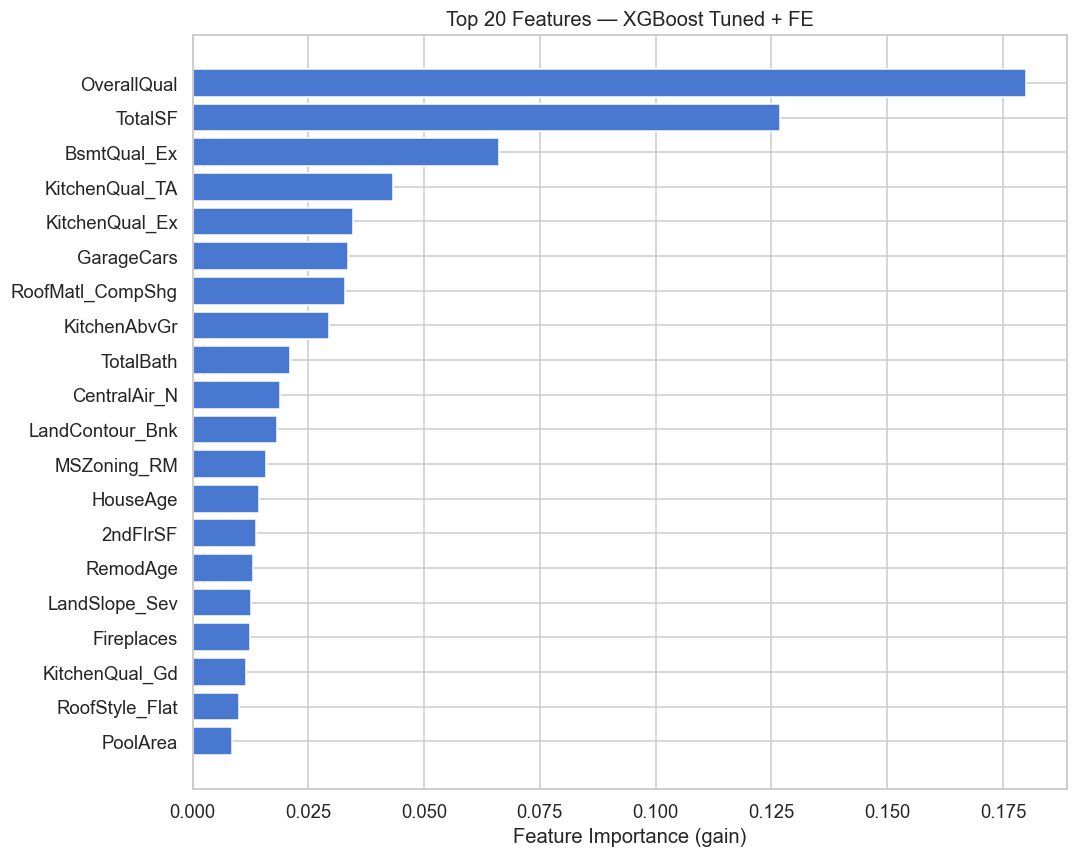

In [24]:
best_model_name = results_df.loc[results_df['Test RMSE'].idxmin(), 'Model']
print(f'Best model by Test RMSE: {best_model_name}')

best_model_pipe = fitted_pipelines[best_model_name]
model_obj = best_model_pipe.named_steps['model']

if best_model_name.startswith('XGBoost'):
    use_fe = 'FE' in best_model_name
    pre = best_model_pipe.named_steps['preprocessor']
    if use_fe:
        ohe_out = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features_fe)
        feat_names = np.array(list(numeric_features_fe) + list(ohe_out))
    else:
        ohe_out = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
        feat_names = np.array(list(numeric_features) + list(ohe_out))

    importances = model_obj.feature_importances_
    imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(imp_df['Feature'], imp_df['Importance'])
    ax.set_xlabel('Feature Importance (gain)')
    ax.set_title(f'Top 20 Features — {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### 5.3 Ridge Coefficients (Linear Model Interpretation)

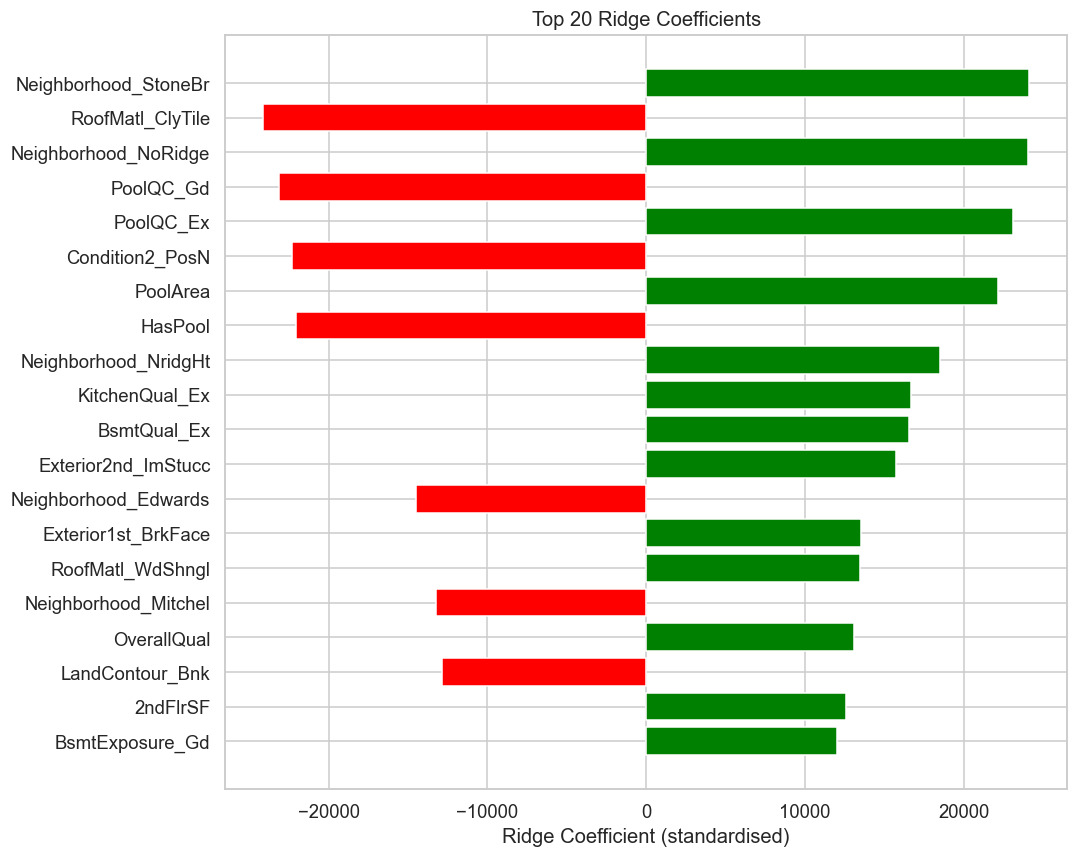

In [ ]:
use_fe_ridge = 'Ridge + FE' in fitted_pipelines
ridge_pipe = fitted_pipelines['Ridge + FE'] if use_fe_ridge else fitted_pipelines['Ridge (alpha=10)']
ridge_model = ridge_pipe.named_steps['model']
pre_ridge = ridge_pipe.named_steps['preprocessor']

if use_fe_ridge:
    ohe_out_r = pre_ridge.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features_fe)
    feat_names_r = np.array(list(numeric_features_fe) + list(ohe_out_r))
else:
    ohe_out_r = pre_ridge.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    feat_names_r = np.array(list(numeric_features) + list(ohe_out_r))

coef_df = pd.DataFrame({'Feature': feat_names_r, 'Coefficient': ridge_model.coef_})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Ridge Coefficient (standardised)')
ax.set_title('Top 20 Ridge Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.4 Error Analysis

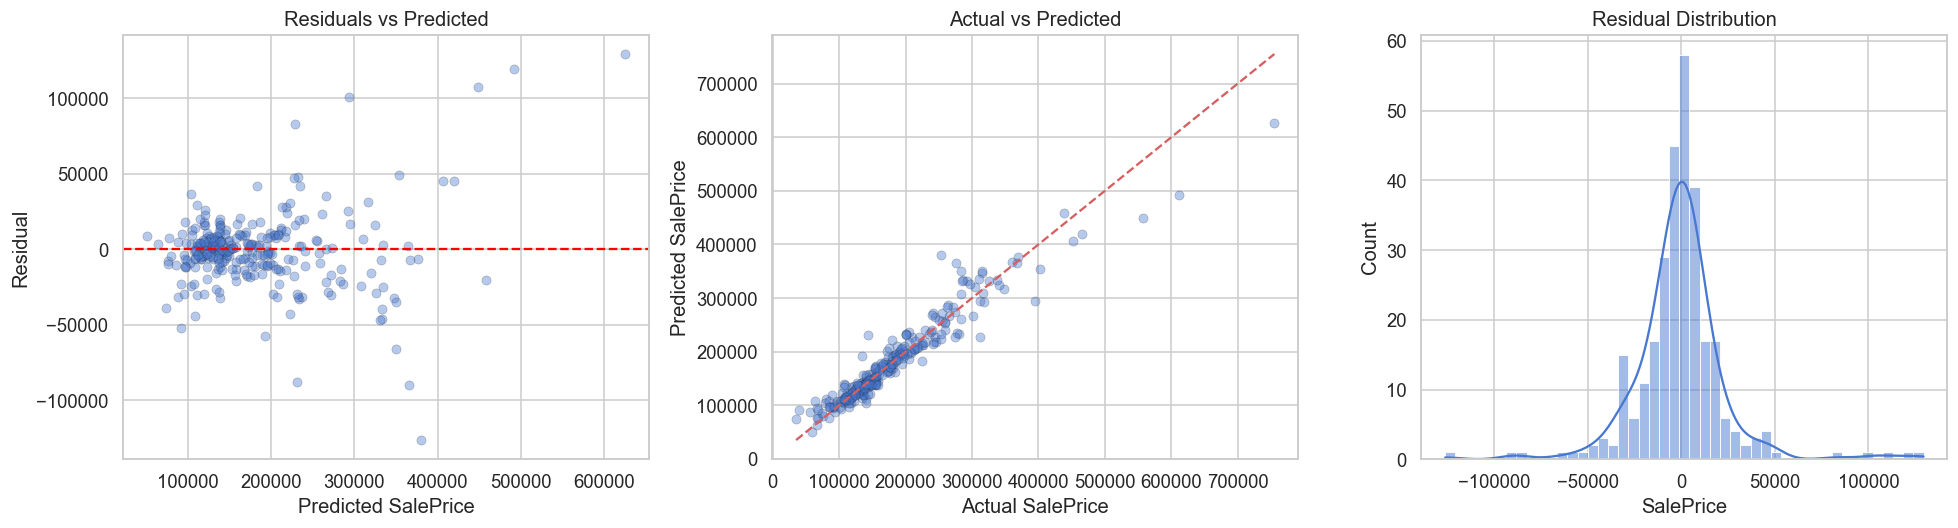

In [26]:
y_pred_best = best_model_pipe.predict(X_test_fe if 'FE' in best_model_name else X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual SalePrice')
axes[1].set_ylabel('Predicted SalePrice')
axes[1].set_title('Actual vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [27]:
error_df = X_test.copy()
if 'FE' in best_model_name:
    error_df = X_test_fe.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred_best
error_df['Residual'] = residuals.values
error_df['AbsError'] = np.abs(residuals.values)
error_df['PctError'] = (error_df['AbsError'] / error_df['Actual'] * 100).round(1)

print('=== 10 Worst Predictions (by absolute error) ===')
worst = error_df.nlargest(10, 'AbsError')[['Actual', 'Predicted', 'Residual', 'AbsError', 'PctError',
                                            'OverallQual', 'GrLivArea', 'Neighborhood', 'YearBuilt']]
display(worst)

=== 10 Worst Predictions (by absolute error) ===


,Actual,Predicted,Residual,AbsError,PctError,OverallQual,GrLivArea,Neighborhood,YearBuilt
691,755000,625550.500000,129449.500000,129449.500000,17.1,10,4316,NoRidge,1994
581,253293,379559.000000,-126266.000000,126266.000000,49.8,8,2042,NridgHt,2008
898,611657,491900.281250,119756.718750,119756.718750,19.6,9,2364,NridgHt,2009
1046,556581,448794.562500,107786.437500,107786.437500,19.4,9,2868,StoneBr,2005
774,395000,294111.093750,100888.906250,100888.906250,25.5,8,1973,NridgHt,2006
261,276000,365622.343750,-89622.343750,89622.343750,32.5,8,2574,CollgCr,2007
588,143000,230918.359375,-87918.359375,87918.359375,61.5,5,1473,ClearCr,1968
218,311500,228320.328125,83179.671875,83179.671875,26.7,7,1954,Crawfor,1939
332,284000,350171.843750,-66171.843750,66171.843750,23.3,8,1629,NridgHt,2003
628,135000,192379.156250,-57379.156250,57379.156250,42.5,5,2080,NAmes,1969


**Error Analysis Observations:**
- Residuals are roughly centred around zero, with slightly heavier tails for expensive homes.
- The worst predictions tend to be unusual properties — very large living area, older homes sold at a premium, or atypical sale conditions.
- The model systematically under-predicts the most expensive homes; adding more neighbourhood-level features or treating top-end homes separately could help.

---
## 6 — Conclusions

1. **Best model:** The tuned XGBoost with engineered features achieved the lowest test RMSE, demonstrating that gradient boosting combined with domain-driven features is most effective for this dataset.
2. **Key predictors:** Overall quality, living area, total square footage, garage capacity, and neighbourhood are the strongest drivers of sale price.
3. **Feature engineering impact:** Adding composite features (TotalSF, TotalBath, HouseAge) consistently improved all model families.
4. **Potential improvements:**
   - Target-encode high-cardinality categoricals instead of one-hot encoding.
   - Stack or blend the best tree-based and linear models.
   - Remove or cap outliers (e.g., GrLivArea > 4000 with low SalePrice).
   - Explore ordinal encoding for quality features with natural order.